# 02 - Feature Engineering
## Produccion de Pozos No Convencionales (Vaca Muerta / YPF)

En este notebook vamos a crear variables nuevas (features) a partir de los
datos ya limpios, para que el modelo de prediccion tenga mas informacion
util sobre el comportamiento de cada pozo a lo largo del tiempo.

Variables que vamos a crear:
1. Antiguedad del pozo (en meses)
2. Produccion del mes anterior (lag)
3. Porcentaje de declinacion mes a mes
4. Ratio gas / petroleo
5. Produccion acumulada del pozo
6. Codigos numericos para las columnas de texto (formacion, cuenca)

In [1]:
import sys
import os

sys.path.append("..")  # para poder importar los archivos que estan en src/

# Jupyter arranca parado en la carpeta "notebooks/", pero data_loader.py
# busca el archivo con la ruta "data/raw/...", que es relativa a la RAIZ
# del proyecto. Por eso nos paramos en la raiz antes de seguir.
if os.getcwd().endswith("notebooks"):
    os.chdir("..")

print("Carpeta de trabajo actual:", os.getcwd())

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.data_loader import cargar_datos
from src.preprocessor import limpiar_datos

sns.set_theme(style="whitegrid")
%matplotlib inline

Carpeta de trabajo actual: /Users/cristianaguilera/Desktop/proyecto-final-data-science


## Paso 1: Cargar y limpiar los datos (como en el notebook 01)

In [2]:
df = cargar_datos()
df = limpiar_datos(df)
print(df.shape)
df.head()

(421046, 39)


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data,anio_completo
0,YSUR,2015,1,132909,16.74,241.220,13.42,0.0,0.0,0.0,...,Neuquén,-69.202207,-39.081820,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2015-01-31,True
1,YSUR,2018,1,132488,0.00,171.937,0.00,0.0,0.0,0.0,...,Rio Negro,-67.864960,-39.016722,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31,True
2,YSUR,2017,1,134325,22.34,365.610,1.20,0.0,0.0,0.0,...,Rio Negro,-67.849735,-39.020644,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31,True
3,YSUR,2018,1,132487,0.00,514.696,17.00,0.0,0.0,0.0,...,Rio Negro,-67.837875,-39.019313,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31,True
4,YSUR,2016,1,153522,234.87,1651.240,94.12,0.0,0.0,0.0,...,Rio Negro,-67.810843,-39.024083,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31,True


## Paso 2: Ordenar los datos

Para calcular cosas como "el mes anterior" o "produccion acumulada", primero
necesitamos que las filas de cada pozo esten en orden cronologico.

In [3]:
df = df.sort_values(["idpozo", "anio", "mes"]).reset_index(drop=True)
df.head()

,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data,anio_completo
0,PEL,2006,2,3640,0.000,0.000,0.000,0.0,0.0,0.0,...,Neuquén,-68.45239,-37.95417,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2006-02-28,True
1,PEL,2006,3,3640,30.808,1.731,30.570,0.0,0.0,0.0,...,Neuquén,-68.45239,-37.95417,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2006-03-31,True
2,PEL,2006,4,3640,76.609,3.713,46.479,0.0,0.0,0.0,...,Neuquén,-68.45239,-37.95417,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2006-04-30,True
3,PEL,2006,5,3640,63.273,4.202,50.536,0.0,0.0,0.0,...,Neuquén,-68.45239,-37.95417,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2006-05-31,True
4,PEL,2006,6,3640,55.043,4.373,52.062,0.0,0.0,0.0,...,Neuquén,-68.45239,-37.95417,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2006-06-30,True


## Paso 3: Antiguedad del pozo

Contamos, para cada pozo, en que numero de mes de produccion esta
(1 = primer mes que aparece en el dataset, 2 = segundo mes, etc.).

In [4]:
df["antiguedad_meses"] = df.groupby("idpozo").cumcount() + 1
df[["idpozo", "anio", "mes", "antiguedad_meses"]].head(10)

,idpozo,anio,mes,antiguedad_meses
0,3640,2006,2,1
1,3640,2006,3,2
2,3640,2006,4,3
3,3640,2006,5,4
4,3640,2006,6,5
5,3640,2006,7,6
6,3640,2006,8,7
7,3640,2006,9,8
8,3640,2006,10,9
9,3640,2006,11,10


## Paso 4: Produccion del mes anterior (lag)

Para cada pozo, guardamos cuanto produjo en el mes anterior. El primer mes
de cada pozo no tiene "mes anterior", asi que va a quedar vacio (NaN) -
eso es esperable, no es un error.

In [5]:
df["prod_pet_mes_anterior"] = df.groupby("idpozo")["prod_pet"].shift(1)
df["prod_gas_mes_anterior"] = df.groupby("idpozo")["prod_gas"].shift(1)

df[["idpozo", "anio", "mes", "prod_pet", "prod_pet_mes_anterior"]].head(10)

,idpozo,anio,mes,prod_pet,prod_pet_mes_anterior
0,3640,2006,2,0.000,NaN
1,3640,2006,3,30.808,0.000
2,3640,2006,4,76.609,30.808
3,3640,2006,5,63.273,76.609
4,3640,2006,6,55.043,63.273
5,3640,2006,7,58.862,55.043
6,3640,2006,8,33.241,58.862
7,3640,2006,9,37.288,33.241
8,3640,2006,10,64.166,37.288
9,3640,2006,11,62.857,64.166


## Paso 5: Porcentaje de declinacion mes a mes

Calculamos cuanto vario la produccion respecto al mes anterior.
Un valor negativo significa que la produccion bajo (lo esperable en
pozos no convencionales, que declinan rapido).

In [6]:
df["declinacion_pet"] = (df["prod_pet"] - df["prod_pet_mes_anterior"]) / df["prod_pet_mes_anterior"]
df["declinacion_gas"] = (df["prod_gas"] - df["prod_gas_mes_anterior"]) / df["prod_gas_mes_anterior"]

# Cuando el mes anterior fue 0, la division da infinito. Lo reemplazamos por NaN
# para no meter valores raros en el modelo.
df["declinacion_pet"] = df["declinacion_pet"].replace([float("inf"), float("-inf")], None)
df["declinacion_gas"] = df["declinacion_gas"].replace([float("inf"), float("-inf")], None)

df[["idpozo", "anio", "mes", "prod_pet", "declinacion_pet"]].head(10)

,idpozo,anio,mes,prod_pet,declinacion_pet
0,3640,2006,2,0.000,NaN
1,3640,2006,3,30.808,None
2,3640,2006,4,76.609,1.486659
3,3640,2006,5,63.273,-0.174079
4,3640,2006,6,55.043,-0.130071
5,3640,2006,7,58.862,0.069382
6,3640,2006,8,33.241,-0.435272
7,3640,2006,9,37.288,0.121747
8,3640,2006,10,64.166,0.720822
9,3640,2006,11,62.857,-0.0204


## Paso 6: Ratio gas / petroleo

Relacion entre la produccion de gas y de petroleo de cada pozo en cada mes.

In [7]:
df["ratio_gas_petroleo"] = df["prod_gas"] / df["prod_pet"]

# De nuevo, si prod_pet es 0 la division da infinito. Lo dejamos como NaN.
df["ratio_gas_petroleo"] = df["ratio_gas_petroleo"].replace([float("inf"), float("-inf")], None)

df[["idpozo", "anio", "mes", "prod_pet", "prod_gas", "ratio_gas_petroleo"]].head(10)

,idpozo,anio,mes,prod_pet,prod_gas,ratio_gas_petroleo
0,3640,2006,2,0.000,0.000,NaN
1,3640,2006,3,30.808,1.731,0.056187
2,3640,2006,4,76.609,3.713,0.048467
3,3640,2006,5,63.273,4.202,0.066411
4,3640,2006,6,55.043,4.373,0.079447
5,3640,2006,7,58.862,3.732,0.063403
6,3640,2006,8,33.241,3.212,0.096628
7,3640,2006,9,37.288,5.669,0.152033
8,3640,2006,10,64.166,5.006,0.078016
9,3640,2006,11,62.857,2.755,0.04383


## Paso 7: Produccion acumulada del pozo

Cuanto lleva producido cada pozo en total, sumando mes a mes.

In [8]:
df["prod_pet_acumulada"] = df.groupby("idpozo")["prod_pet"].cumsum()
df["prod_gas_acumulada"] = df.groupby("idpozo")["prod_gas"].cumsum()

df[["idpozo", "anio", "mes", "prod_pet", "prod_pet_acumulada"]].head(10)

,idpozo,anio,mes,prod_pet,prod_pet_acumulada
0,3640,2006,2,0.000,0.000
1,3640,2006,3,30.808,30.808
2,3640,2006,4,76.609,107.417
3,3640,2006,5,63.273,170.690
4,3640,2006,6,55.043,225.733
5,3640,2006,7,58.862,284.595
6,3640,2006,8,33.241,317.836
7,3640,2006,9,37.288,355.124
8,3640,2006,10,64.166,419.290
9,3640,2006,11,62.857,482.147


## Paso 8: Convertir texto a numeros (encoding)

Los modelos de Machine Learning no entienden texto, necesitan numeros.
Le asignamos un codigo numerico a cada formacion y cada cuenca.

In [9]:
df["formacion_cod"] = df["formacion"].astype("category").cat.codes
df["cuenca_cod"] = df["cuenca"].astype("category").cat.codes

df[["formacion", "formacion_cod", "cuenca", "cuenca_cod"]].drop_duplicates().head(10)

,formacion,formacion_cod,cuenca,cuenca_cod
0,vaca muerta,27,NEUQUINA,2
492,lajas,10,NEUQUINA,2
739,magallanes,14,AUSTRAL,0
1478,lotena,13,NEUQUINA,2
1724,punta rosada,20,NEUQUINA,2
3205,mulichinco,16,NEUQUINA,2
6169,quintuco,21,NEUQUINA,2
6416,los molles,12,NEUQUINA,2
13075,precuyo,19,NEUQUINA,2
15545,sierras blancas,23,NEUQUINA,2


## Paso 9: Chequeo visual - curva de declinacion de un pozo

Elegimos un pozo con bastante historia y graficamos su produccion mes a mes,
para confirmar que las variables nuevas (antiguedad, acumulada) tienen sentido.

Pozo elegido: 10073


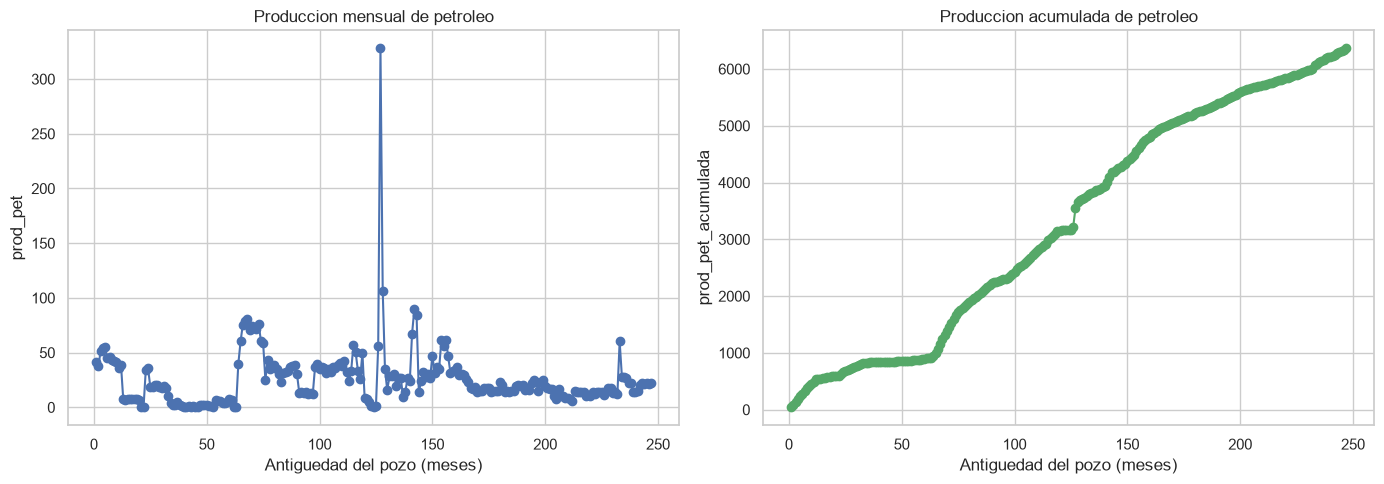

In [10]:
# Buscamos el pozo con mas meses de historia cargados
pozo_con_mas_historia = df.groupby("idpozo")["antiguedad_meses"].max().idxmax()
print("Pozo elegido:", pozo_con_mas_historia)

datos_pozo = df[df["idpozo"] == pozo_con_mas_historia]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(datos_pozo["antiguedad_meses"], datos_pozo["prod_pet"], marker="o")
axes[0].set_title("Produccion mensual de petroleo")
axes[0].set_xlabel("Antiguedad del pozo (meses)")
axes[0].set_ylabel("prod_pet")

axes[1].plot(datos_pozo["antiguedad_meses"], datos_pozo["prod_pet_acumulada"], marker="o", color="#55A868")
axes[1].set_title("Produccion acumulada de petroleo")
axes[1].set_xlabel("Antiguedad del pozo (meses)")
axes[1].set_ylabel("prod_pet_acumulada")

plt.tight_layout()
plt.show()

**Que deberiamos ver:** la produccion mensual (grafico izquierdo) deberia
mostrar la curva tipica de un pozo no convencional: sube rapido al principio
y despues declina. La produccion acumulada (grafico derecho) deberia ser una
curva que siempre sube (nunca baja, porque es una suma acumulada).

## Paso 10: Guardar el dataset con las variables nuevas

Guardamos el resultado en `data/processed/` para que el notebook de
modelado (03) lo pueda usar directamente, sin tener que repetir todos
estos pasos de nuevo.

In [11]:
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/produccion_con_features.csv", index=False)
print("Guardado en data/processed/produccion_con_features.csv")
print("Filas y columnas:", df.shape)

Guardado en data/processed/produccion_con_features.csv
Filas y columnas: (421046, 49)


## Conclusiones

- Se crearon 8 variables nuevas: `antiguedad_meses`, `prod_pet_mes_anterior`,
  `prod_gas_mes_anterior`, `declinacion_pet`, `declinacion_gas`,
  `ratio_gas_petroleo`, `prod_pet_acumulada`, `prod_gas_acumulada`,
  ademas de los codigos numericos `formacion_cod` y `cuenca_cod`.
- Las variables de "mes anterior" y "declinacion" quedan vacias (NaN) en el
  primer mes de cada pozo — es esperable, y el modelo de la Pre-Entrega 3
  va a tener que decidir como manejar esas filas (descartarlas o imputarlas).
- El grafico de chequeo confirmo que la curva de produccion y la acumulada
  tienen la forma esperada para un pozo no convencional.

**Proximo paso:** `03_modelado_supervisado.ipynb` — entrenar el modelo de
regresion (XGBoost / LightGBM) usando `data/processed/produccion_con_features.csv`.